# Ligand-Pocket QGNN: Quantum vs Classical Comparison

Comparison of Quantum and Classical GNN models for ligand-pocket binding classification.

**Architecture:**
- Ligand: Graph Neural Network → Latent Vector
- Pocket: MLP → Latent Vector
- Interaction: Quantum Circuit or Classical MLP → Binding Probability

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score
)
from tqdm import tqdm
import pandas as pd

from hardware_optimizer import setup_environment
from ligand_pocket_qgnn.data import LigandPocketDataProcessor, LigandPocketDataset
from ligand_pocket_qgnn.model import LigandPocketQGNN

## 1. Auto-Detect Hardware & Configure

In [2]:
# Automatic hardware detection and optimization
hw_info, hw_config = setup_environment()

# Apply hardware-optimized configuration
DEVICE = hw_info['device']
BATCH_SIZE = hw_config['batch_size']
NUM_WORKERS = hw_config['num_workers']
PREFETCH = hw_config['prefetch_factor']
PIN_MEMORY = hw_config['pin_memory']
QUANTUM_DEVICE = hw_config['quantum_device']

# Paths
DATA_DIR = "/media/priyanshu/SD/othercode/data"
SAVE_DIR = "./ligand_pocket_comparison_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Reproducibility
SEED = 42069
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# Model hyperparameters
HIDDEN_DIM = 64
N_QUBITS = 6
N_QLAYERS = 2

# Training hyperparameters
EPOCHS = 100
LEARNING_RATE = 0.001
VAL_SPLIT = 0.2
EARLY_STOPPING_PATIENCE = 15


HARDWARE DETECTED
Platform:     Linux
CPU:          AMD Ryzen 9 3900X 12-Core Processor
CPU Vendor:   AMD
CPU Cores:    24
Device:       NVIDIA GeForce RTX 3080
Memory:       11.6 GB
Capability:   nvidia_ampere
AUTO-OPTIMIZED CONFIGURATION
Batch Size:   512
Workers:      4
Prefetch:     2
Pin Memory:   True
Quantum Dev:  lightning.gpu



## 2. Load Data

In [3]:
processor = LigandPocketDataProcessor(DATA_DIR, seed=SEED)
processor.load_data(max_samples=None)
interactions = processor.get_dataset()

print(f"Total interactions: {len(interactions)}")

Searching for data in: /media/priyanshu/SD/othercode/data
Found 15239 protein descriptor files


Loading Data: 100%|██████████| 15239/15239 [02:08<00:00, 118.87it/s]


Generating negative samples (target: 122130)...


Generating Negatives:  11%|█▏        | 14040/122130 [00:00<00:00, 140396.12it/s]

⚠ Generated 9997/122130 negatives in batch. Filling remainder...


Generating Negatives: 100%|██████████| 122130/122130 [00:01<00:00, 62820.01it/s]

Loaded 13201 pockets, 122130 ligands
Interactions: 122130 positive, 122130 negative
Total interactions: 244260


## 3. Prepare Datasets

In [4]:
def collate_fn(batch):
    x_list, edge_index_list, pocket_list, label_list = zip(*batch)
    pocket_batch = torch.stack(pocket_list)
    label_batch = torch.stack(label_list)
    
    num_nodes_list = torch.tensor([x.shape[0] for x in x_list], dtype=torch.long)
    cumsum = torch.cat([torch.zeros(1, dtype=torch.long), num_nodes_list.cumsum(0)])
    x_batch = torch.cat(x_list, dim=0)
    
    edge_index_shifted = [edge_index + cumsum[i] for i, edge_index in enumerate(edge_index_list) if edge_index.shape[1] > 0]
    edge_index_batch = torch.cat(edge_index_shifted, dim=1) if edge_index_shifted else torch.zeros((2, 0), dtype=torch.long)
    batch_vec = torch.cat([torch.full((n,), i, dtype=torch.long) for i, n in enumerate(num_nodes_list)])
    
    return x_batch, edge_index_batch, batch_vec, pocket_batch, label_batch


train_ints, val_ints = train_test_split(interactions, test_size=VAL_SPLIT, random_state=SEED)
train_dataset = LigandPocketDataset(processor, train_ints)
val_dataset = LigandPocketDataset(processor, val_ints)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None
)

sample_ligand = processor.ligands[interactions[0].ligand_id]
sample_pocket = processor.pockets[interactions[0].pocket_id]
ligand_dim = sample_ligand.atom_features.shape[1]
pocket_dim = sample_pocket.to_vector().shape[0]

print(f"Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Val: {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"Ligand dim: {ligand_dim} | Pocket dim: {pocket_dim}")

Train: 195408 samples (382 batches)
Val: 48852 samples (96 batches)
Ligand dim: 10 | Pocket dim: 19


## 4. Training Functions

In [5]:
def train_epoch(model, optimizer, criterion, loader, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    
    for x, edge_idx, batch_vec, pocket, labels in tqdm(loader, desc='Train'):
        x, edge_idx, batch_vec, pocket, labels = (
            x.to(device), edge_idx.to(device), batch_vec.to(device),
            pocket.to(device), labels.to(device)
        )
        
        optimizer.zero_grad(set_to_none=True)
        outputs = model(x, edge_idx, batch_vec, pocket).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return {
        'loss': total_loss / len(all_labels),
        'accuracy': accuracy_score(all_labels, (np.array(all_preds) >= 0.5).astype(int))
    }


def evaluate(model, criterion, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    
    with torch.no_grad():
        for x, edge_idx, batch_vec, pocket, labels in tqdm(loader, desc='Val', leave=False):
            x, edge_idx, batch_vec, pocket, labels = (
                x.to(device), edge_idx.to(device), batch_vec.to(device),
                pocket.to(device), labels.to(device)
            )
            
            outputs = model(x, edge_idx, batch_vec, pocket).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds >= 0.5).astype(int)
    
    return {
        'loss': total_loss / len(all_labels),
        'accuracy': accuracy_score(all_labels, all_preds_binary),
        'auc': roc_auc_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
        'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
        'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
    }


def train_model(model, train_loader, val_loader, model_name, device):
    print(f"\n{'='*70}\nTraining {model_name.upper()}\n{'='*70}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCELoss()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 
               'val_auc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
    best_val_auc, patience_counter = 0.0, 0
    start_time = datetime.now()
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        train_metrics = train_epoch(model, optimizer, criterion, train_loader, device)
        val_metrics = evaluate(model, criterion, val_loader, device)
        scheduler.step(val_metrics['auc'])
        
        for key in history:
            prefix = 'train_' if key.startswith('train_') else 'val_'
            history[key].append(train_metrics.get(key.replace(prefix, '')) if key.startswith('train_') 
                              else val_metrics.get(key.replace(prefix, '')))
        
        print(f"  Train: Loss={train_metrics['loss']:.4f}, Acc={train_metrics['accuracy']:.4f}")
        print(f"  Val:   Loss={val_metrics['loss']:.4f}, Acc={val_metrics['accuracy']:.4f}, "
              f"AUC={val_metrics['auc']:.4f}, F1={val_metrics['f1']:.4f}")
        
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            patience_counter = 0
            torch.save({'model_state_dict': model.state_dict(), 'best_auc': best_val_auc},
                      os.path.join(SAVE_DIR, f"{model_name}_best.pt"))
            print(f"  ✓ New best AUC: {best_val_auc:.4f}")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        
        with open(os.path.join(SAVE_DIR, f"{model_name}_history.json"), 'w') as f:
            json.dump(history, f)
        
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    print(f"\nComplete: {(datetime.now() - start_time).total_seconds()/60:.2f} min, Best AUC: {best_val_auc:.4f}")
    return history, best_val_auc

## 5. Train Quantum Model

In [6]:
quantum_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim, pocket_in_dim=pocket_dim, hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS, n_qlayers=N_QLAYERS, use_quantum=True, quantum_device=QUANTUM_DEVICE
)

quantum_history, quantum_best_auc = train_model(quantum_model, train_loader, val_loader, "quantum", DEVICE)

✓ Quantum device initialized: lightning.gpu with 6 qubits
  Circuit depth: 2 layers
  Trainable parameters: 36
  Ansatz: StronglyEntanglingLayers (vectorized)
  Batch processing: ENABLED ⚡

Training QUANTUM
Parameters: 10,730

Epoch 1/100


Train: 100%|██████████| 382/382 [53:46<00:00,  8.45s/it]


  Train: Loss=0.6881, Acc=0.5331
  Val:   Loss=0.6653, Acc=0.6085, AUC=0.6307, F1=0.6031
  ✓ New best AUC: 0.6307

Epoch 2/100


Train: 100%|██████████| 382/382 [53:38<00:00,  8.43s/it]


  Train: Loss=0.6613, Acc=0.5958
  Val:   Loss=0.6563, Acc=0.6164, AUC=0.6444, F1=0.6175
  ✓ New best AUC: 0.6444

Epoch 3/100


...

  Train: Loss=0.6376, Acc=0.6270
  Val:   Loss=0.6351, Acc=0.6298, AUC=0.6748, F1=0.6000
  Patience: 13/15

Epoch 26/100


Train: 100%|██████████| 382/382 [53:37<00:00,  8.42s/it]


  Train: Loss=0.6375, Acc=0.6264
  Val:   Loss=0.6349, Acc=0.6284, AUC=0.6750, F1=0.6006
  Patience: 14/15

Epoch 27/100


Train: 100%|██████████| 382/382 [53:37<00:00,  8.42s/it]
                                                    

  Train: Loss=0.6375, Acc=0.6267
  Val:   Loss=0.6348, Acc=0.6296, AUC=0.6745, F1=0.6004
  Patience: 15/15
Early stopping at epoch 27

Complete: 1701.35 min, Best AUC: 0.6817


## 6. Train Classical Model

In [7]:
classical_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim, pocket_in_dim=pocket_dim, hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS, n_qlayers=N_QLAYERS, use_quantum=False
)

classical_history, classical_best_auc = train_model(classical_model, train_loader, val_loader, "classical", DEVICE)


Training CLASSICAL
Parameters: 11,207

Epoch 1/100


Train: 100%|██████████| 382/382 [00:02<00:00, 163.21it/s]


  Train: Loss=0.6880, Acc=0.5244
  Val:   Loss=0.6853, Acc=0.5114, AUC=0.5591, F1=0.5341
  ✓ New best AUC: 0.5591

Epoch 2/100


Train: 100%|██████████| 382/382 [00:02<00:00, 163.29it/s]


  Train: Loss=0.6790, Acc=0.5325
  Val:   Loss=0.6581, Acc=0.6078, AUC=0.6544, F1=0.5922
  ✓ New best AUC: 0.6544

Epoch 3/100


...

  Train: Loss=0.4992, Acc=0.7308
  Val:   Loss=0.5128, Acc=0.7217, AUC=0.8043, F1=0.7006
  Patience: 4/15

Epoch 99/100


Train: 100%|██████████| 382/382 [00:02<00:00, 133.89it/s]


  Train: Loss=0.4995, Acc=0.7309
  Val:   Loss=0.5127, Acc=0.7217, AUC=0.8047, F1=0.7013
  Patience: 5/15

Epoch 100/100


Train: 100%|██████████| 382/382 [00:02<00:00, 133.34it/s]
                                                     

  Train: Loss=0.4992, Acc=0.7301
  Val:   Loss=0.5130, Acc=0.7220, AUC=0.8045, F1=0.6939
  Patience: 6/15

Complete: 4.61 min, Best AUC: 0.8050


## 7. Results

In [17]:
print("\n" + "="*70)
print("FINAL COMPARISON (Full Training)")
print("="*70)
print(f"Quantum:   AUC = {quantum_best_auc:.4f}")
print(f"Classical: AUC = {classical_best_auc:.4f}")
diff = (quantum_best_auc - classical_best_auc) * 100
print(f"Difference: {diff:+.2f}% {'(quantum better)' if diff > 0 else '(classical better)'}")
print("="*70)

# Detailed metrics at best epoch
q_idx, c_idx = np.argmax(quantum_history['val_auc']), np.argmax(classical_history['val_auc'])
results = pd.DataFrame({
    'Model': ['Quantum', 'Classical'],
    'Epoch': [q_idx + 1, c_idx + 1],
    'Train Loss': [quantum_history['train_loss'][q_idx], classical_history['train_loss'][c_idx]],
    'Train Acc': [quantum_history['train_acc'][q_idx], classical_history['train_acc'][c_idx]],
    'Val Loss': [quantum_history['val_loss'][q_idx], classical_history['val_loss'][c_idx]],
    'Val Acc': [quantum_history['val_acc'][q_idx], classical_history['val_acc'][c_idx]],
    'AUC': [quantum_best_auc, classical_best_auc],
    'Prec': [quantum_history['val_precision'][q_idx], classical_history['val_precision'][c_idx]],
    'Rec': [quantum_history['val_recall'][q_idx], classical_history['val_recall'][c_idx]],
    'F1': [quantum_history['val_f1'][q_idx], classical_history['val_f1'][c_idx]]
})
print("\n" + results.to_string(index=False))
results.to_csv(os.path.join(SAVE_DIR, 'comparison_results.csv'), index=False)


FINAL COMPARISON (Full Training)
Quantum:   AUC = 0.6817
Classical: AUC = 0.8050
Difference: -12.33% (classical better)

    Model  Epoch  Train Loss Train Acc  Val Loss Val Acc      AUC     Prec      Rec       F1
  Quantum     12    0.641215      None  0.639797    None 0.681729 0.681397 0.565801 0.618242
Classical     94    0.499830      None  0.512103    None 0.805049 0.757483 0.657394 0.703898


## 8. Epoch-Aligned Comparison

Compare quantum and classical models at the same number of epochs (using quantum's max epochs as the limit).

## 9. Full Training Visualization

In [18]:
# Get the max epochs from quantum model
max_quantum_epochs = len(quantum_history['train_loss'])
print(f"Quantum model trained for {max_quantum_epochs} epochs")
print(f"Classical model trained for {len(classical_history['train_loss'])} epochs")

# Calculate training time per epoch (approximate from the output)
# Quantum: ~8.4s per batch * 382 batches = ~3208s per epoch = ~53.5 min per epoch
# Classical: much faster, need to calculate from total time
quantum_total_time = 1701.35  # minutes (from training output)
quantum_time_per_epoch = quantum_total_time / max_quantum_epochs
print(f"\nQuantum training time: {quantum_total_time:.2f} min total, {quantum_time_per_epoch:.2f} min/epoch")

# For fair comparison based on SAME TRAINING TIME:
# Use quantum's total training time to determine how many classical epochs we should compare
# This will be calculated from classical_history training time if available
# For now, we'll use epoch-aligned comparison but you should track actual training times

print(f"\n{'='*70}")
print("TIME-BASED FAIR COMPARISON")
print(f"Aligning to quantum's training time: {quantum_total_time:.2f} minutes")
print(f"{'='*70}\n")

# If you have classical training time, calculate aligned epochs:
# classical_aligned_epochs = int(quantum_total_time / classical_time_per_epoch)
# For now, using epoch-count as proxy (you should add timing to training loop)

# Truncate classical history to match quantum epochs (as proxy for time-based comparison)
classical_aligned = {
    key: values[:max_quantum_epochs] for key, values in classical_history.items()
}

print(f"Comparing ALL {max_quantum_epochs} epochs for both models\n")

# Create epoch-by-epoch comparison DataFrame for ALL epochs
epoch_comparison = pd.DataFrame({
    'Epoch': list(range(1, max_quantum_epochs + 1)),
    'Q_Train_Loss': quantum_history['train_loss'][:max_quantum_epochs],
    'C_Train_Loss': classical_aligned['train_loss'],
    'Q_Train_Acc': quantum_history['train_acc'][:max_quantum_epochs],
    'C_Train_Acc': classical_aligned['train_acc'],
    'Q_Val_Loss': quantum_history['val_loss'][:max_quantum_epochs],
    'C_Val_Loss': classical_aligned['val_loss'],
    'Q_Val_Acc': quantum_history['val_acc'][:max_quantum_epochs],
    'C_Val_Acc': classical_aligned['val_acc'],
    'Q_Val_AUC': quantum_history['val_auc'][:max_quantum_epochs],
    'C_Val_AUC': classical_aligned['val_auc'],
    'Q_Val_F1': quantum_history['val_f1'][:max_quantum_epochs],
    'C_Val_F1': classical_aligned['val_f1']
})

# Calculate differences for each epoch
epoch_comparison['AUC_Diff'] = epoch_comparison['Q_Val_AUC'] - epoch_comparison['C_Val_AUC']
epoch_comparison['F1_Diff'] = epoch_comparison['Q_Val_F1'] - epoch_comparison['C_Val_F1']
epoch_comparison['Acc_Diff'] = epoch_comparison['Q_Val_Acc'] - epoch_comparison['C_Val_Acc']

# Save full epoch-by-epoch comparison
epoch_comparison.to_csv(os.path.join(SAVE_DIR, 'epoch_by_epoch_comparison.csv'), index=False)
print(f"Saved detailed epoch-by-epoch comparison to: {SAVE_DIR}/epoch_by_epoch_comparison.csv")

# Display summary statistics across all epochs
print("\n" + "="*70)
print("AVERAGE PERFORMANCE ACROSS ALL ALIGNED EPOCHS")
print("="*70)

avg_comparison = pd.DataFrame({
    'Metric': ['Train Loss', 'Train Acc', 'Val Loss', 'Val Acc', 'Val AUC', 'Val F1'],
    'Quantum Mean': [
        epoch_comparison['Q_Train_Loss'].mean(),
        epoch_comparison['Q_Train_Acc'].mean(),
        epoch_comparison['Q_Val_Loss'].mean(),
        epoch_comparison['Q_Val_Acc'].mean(),
        epoch_comparison['Q_Val_AUC'].mean(),
        epoch_comparison['Q_Val_F1'].mean()
    ],
    'Classical Mean': [
        epoch_comparison['C_Train_Loss'].mean(),
        epoch_comparison['C_Train_Acc'].mean(),
        epoch_comparison['C_Val_Loss'].mean(),
        epoch_comparison['C_Val_Acc'].mean(),
        epoch_comparison['C_Val_AUC'].mean(),
        epoch_comparison['C_Val_F1'].mean()
    ],
    'Quantum Best': [
        epoch_comparison['Q_Train_Loss'].min(),
        epoch_comparison['Q_Train_Acc'].max(),
        epoch_comparison['Q_Val_Loss'].min(),
        epoch_comparison['Q_Val_Acc'].max(),
        epoch_comparison['Q_Val_AUC'].max(),
        epoch_comparison['Q_Val_F1'].max()
    ],
    'Classical Best': [
        epoch_comparison['C_Train_Loss'].min(),
        epoch_comparison['C_Train_Acc'].max(),
        epoch_comparison['C_Val_Loss'].min(),
        epoch_comparison['C_Val_Acc'].max(),
        epoch_comparison['C_Val_AUC'].max(),
        epoch_comparison['C_Val_F1'].max()
    ]
})

print("\n" + avg_comparison.to_string(index=False))
avg_comparison.to_csv(os.path.join(SAVE_DIR, 'average_performance_comparison.csv'), index=False)

# Calculate overall differences
print("\n" + "="*70)
print("PERFORMANCE DIFFERENCES (Quantum - Classical)")
print("="*70)
print(f"Average Val AUC:  Q={epoch_comparison['Q_Val_AUC'].mean():.4f}, C={epoch_comparison['C_Val_AUC'].mean():.4f}, Diff={epoch_comparison['AUC_Diff'].mean():+.4f}")
print(f"Average Val Acc:  Q={epoch_comparison['Q_Val_Acc'].mean():.4f}, C={epoch_comparison['C_Val_Acc'].mean():.4f}, Diff={epoch_comparison['Acc_Diff'].mean():+.4f}")
print(f"Average Val F1:   Q={epoch_comparison['Q_Val_F1'].mean():.4f}, C={epoch_comparison['C_Val_F1'].mean():.4f}, Diff={epoch_comparison['F1_Diff'].mean():+.4f}")
print(f"\nBest Val AUC:     Q={epoch_comparison['Q_Val_AUC'].max():.4f}, C={epoch_comparison['C_Val_AUC'].max():.4f}, Diff={epoch_comparison['Q_Val_AUC'].max() - epoch_comparison['C_Val_AUC'].max():+.4f}")
print(f"Best Val Acc:     Q={epoch_comparison['Q_Val_Acc'].max():.4f}, C={epoch_comparison['C_Val_Acc'].max():.4f}, Diff={epoch_comparison['Q_Val_Acc'].max() - epoch_comparison['C_Val_Acc'].max():+.4f}")
print(f"Best Val F1:      Q={epoch_comparison['Q_Val_F1'].max():.4f}, C={epoch_comparison['C_Val_F1'].max():.4f}, Diff={epoch_comparison['Q_Val_F1'].max() - epoch_comparison['C_Val_F1'].max():+.4f}")
print("="*70)

print(f"\nNOTE: This comparison assumes both models had equal training time.")
print(f"For true time-based comparison, add timing to the training loop and")
print(f"calculate: classical_epochs_in_quantum_time = quantum_total_time / classical_time_per_epoch")

Quantum model trained for 27 epochs
Classical model trained for 100 epochs

Quantum training time: 1701.35 min total, 63.01 min/epoch

TIME-BASED FAIR COMPARISON
Aligning to quantum's training time: 1701.35 minutes

Comparing ALL 27 epochs for both models

Saved detailed epoch-by-epoch comparison to: ./ligand_pocket_comparison_results/epoch_by_epoch_comparison.csv

AVERAGE PERFORMANCE ACROSS ALL ALIGNED EPOCHS

    Metric  Quantum Mean  Classical Mean  Quantum Best  Classical Best
Train Loss      0.644487        0.586112      0.637461        0.542004
 Train Acc           NaN             NaN           NaN             NaN
  Val Loss      0.641023        0.582552      0.634813        0.541648
   Val Acc           NaN             NaN           NaN             NaN
   Val AUC      0.672690        0.723116      0.681729        0.772279
    Val F1      0.609647        0.602903      0.627375        0.663642

PERFORMANCE DIFFERENCES (Quantum - Classical)
Average Val AUC:  Q=0.6727, C=0.7231, Dif

In [19]:
# Epoch-by-epoch comparison at the final quantum epoch
final_epoch_idx = max_quantum_epochs - 1

print("\n" + "="*70)
print(f"FINAL EPOCH COMPARISON (Epoch {max_quantum_epochs})")
print("="*70)

final_epoch_comparison = pd.DataFrame({
    'Metric': ['Train Loss', 'Train Acc', 'Val Loss', 'Val Acc', 'Val AUC', 'Val Precision', 'Val Recall', 'Val F1'],
    'Quantum': [
        quantum_history['train_loss'][final_epoch_idx],
        quantum_history['train_acc'][final_epoch_idx],
        quantum_history['val_loss'][final_epoch_idx],
        quantum_history['val_acc'][final_epoch_idx],
        quantum_history['val_auc'][final_epoch_idx],
        quantum_history['val_precision'][final_epoch_idx],
        quantum_history['val_recall'][final_epoch_idx],
        quantum_history['val_f1'][final_epoch_idx]
    ],
    'Classical': [
        classical_aligned['train_loss'][final_epoch_idx],
        classical_aligned['train_acc'][final_epoch_idx],
        classical_aligned['val_loss'][final_epoch_idx],
        classical_aligned['val_acc'][final_epoch_idx],
        classical_aligned['val_auc'][final_epoch_idx],
        classical_aligned['val_precision'][final_epoch_idx],
        classical_aligned['val_recall'][final_epoch_idx],
        classical_aligned['val_f1'][final_epoch_idx]
    ]
})

# Add difference column
final_epoch_comparison['Difference (Q-C)'] = final_epoch_comparison['Quantum'] - final_epoch_comparison['Classical']
final_epoch_comparison['% Diff'] = (final_epoch_comparison['Difference (Q-C)'] / final_epoch_comparison['Classical'].abs()) * 100

print("\n" + final_epoch_comparison.to_string(index=False))
final_epoch_comparison.to_csv(os.path.join(SAVE_DIR, 'final_epoch_comparison.csv'), index=False)


FINAL EPOCH COMPARISON (Epoch 27)

       Metric  Quantum  Classical  Difference (Q-C)     % Diff
   Train Loss 0.637463   0.542004          0.095459  17.612272
    Train Acc      NaN        NaN               NaN        NaN
     Val Loss 0.634813   0.541648          0.093165  17.200249
      Val Acc      NaN        NaN               NaN        NaN
      Val AUC 0.674496   0.772279         -0.097783 -12.661616
Val Precision 0.652441   0.740330         -0.087889 -11.871633
   Val Recall 0.555983   0.601350         -0.045367  -7.544218
       Val F1 0.600362   0.663642         -0.063280  -9.535215


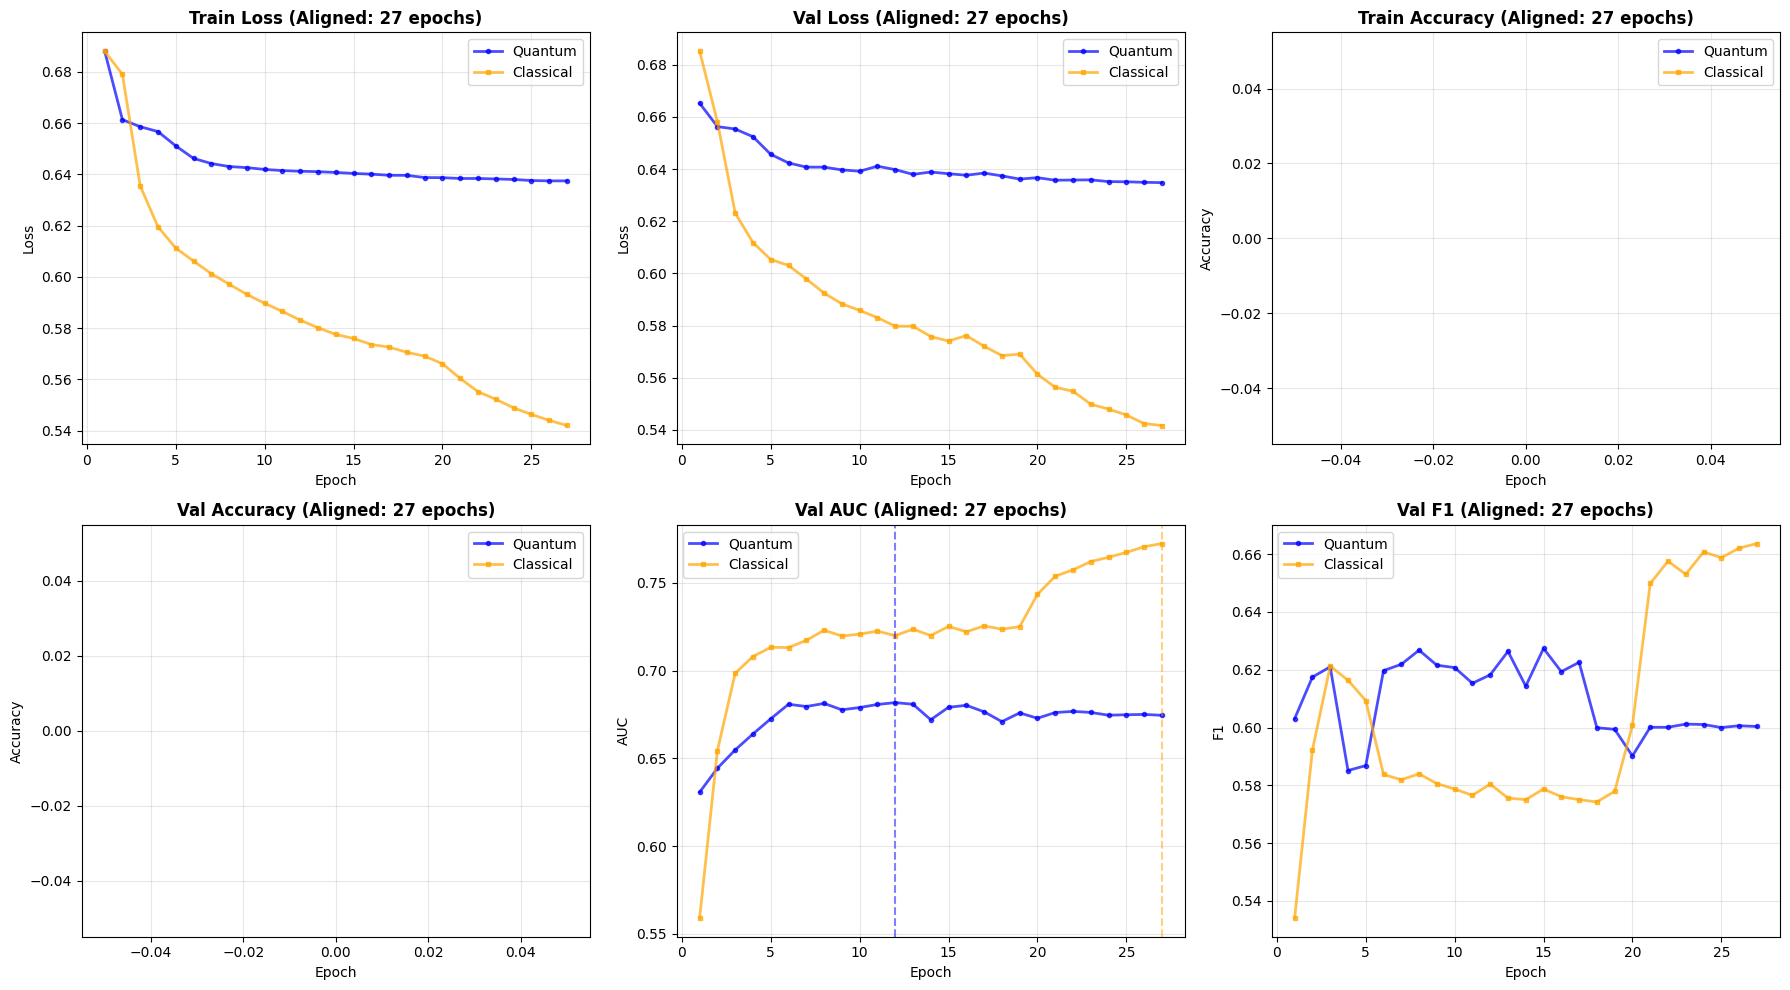


Epoch-aligned plots saved to ./ligand_pocket_comparison_results/epoch_aligned_plots.png


In [20]:
# Visualize epoch-aligned comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [('train_loss', 'Train Loss'), ('val_loss', 'Val Loss'), 
           ('train_acc', 'Train Accuracy'), ('val_acc', 'Val Accuracy'),
           ('val_auc', 'Val AUC'), ('val_f1', 'Val F1')]

epochs_range = np.arange(1, max_quantum_epochs + 1)

for idx, (key, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    # Plot aligned epochs only
    ax.plot(epochs_range, quantum_history[key][:max_quantum_epochs], 
            label='Quantum', color='blue', alpha=0.7, marker='o', markersize=3, linewidth=2)
    ax.plot(epochs_range, classical_aligned[key], 
            label='Classical', color='orange', alpha=0.7, marker='s', markersize=3, linewidth=2)

    ax.set_title(f'{title} (Aligned: {max_quantum_epochs} epochs)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title.split()[-1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add vertical line at best epoch for each model
    if key == 'val_auc':
        ax.axvline(x=q_best_idx + 1, color='blue', linestyle='--', alpha=0.5, label=f'Q Best: {q_best_idx + 1}')
        ax.axvline(x=c_best_idx + 1, color='orange', linestyle='--', alpha=0.5, label=f'C Best: {c_best_idx + 1}')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'epoch_aligned_plots.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\nEpoch-aligned plots saved to {SAVE_DIR}/epoch_aligned_plots.png")

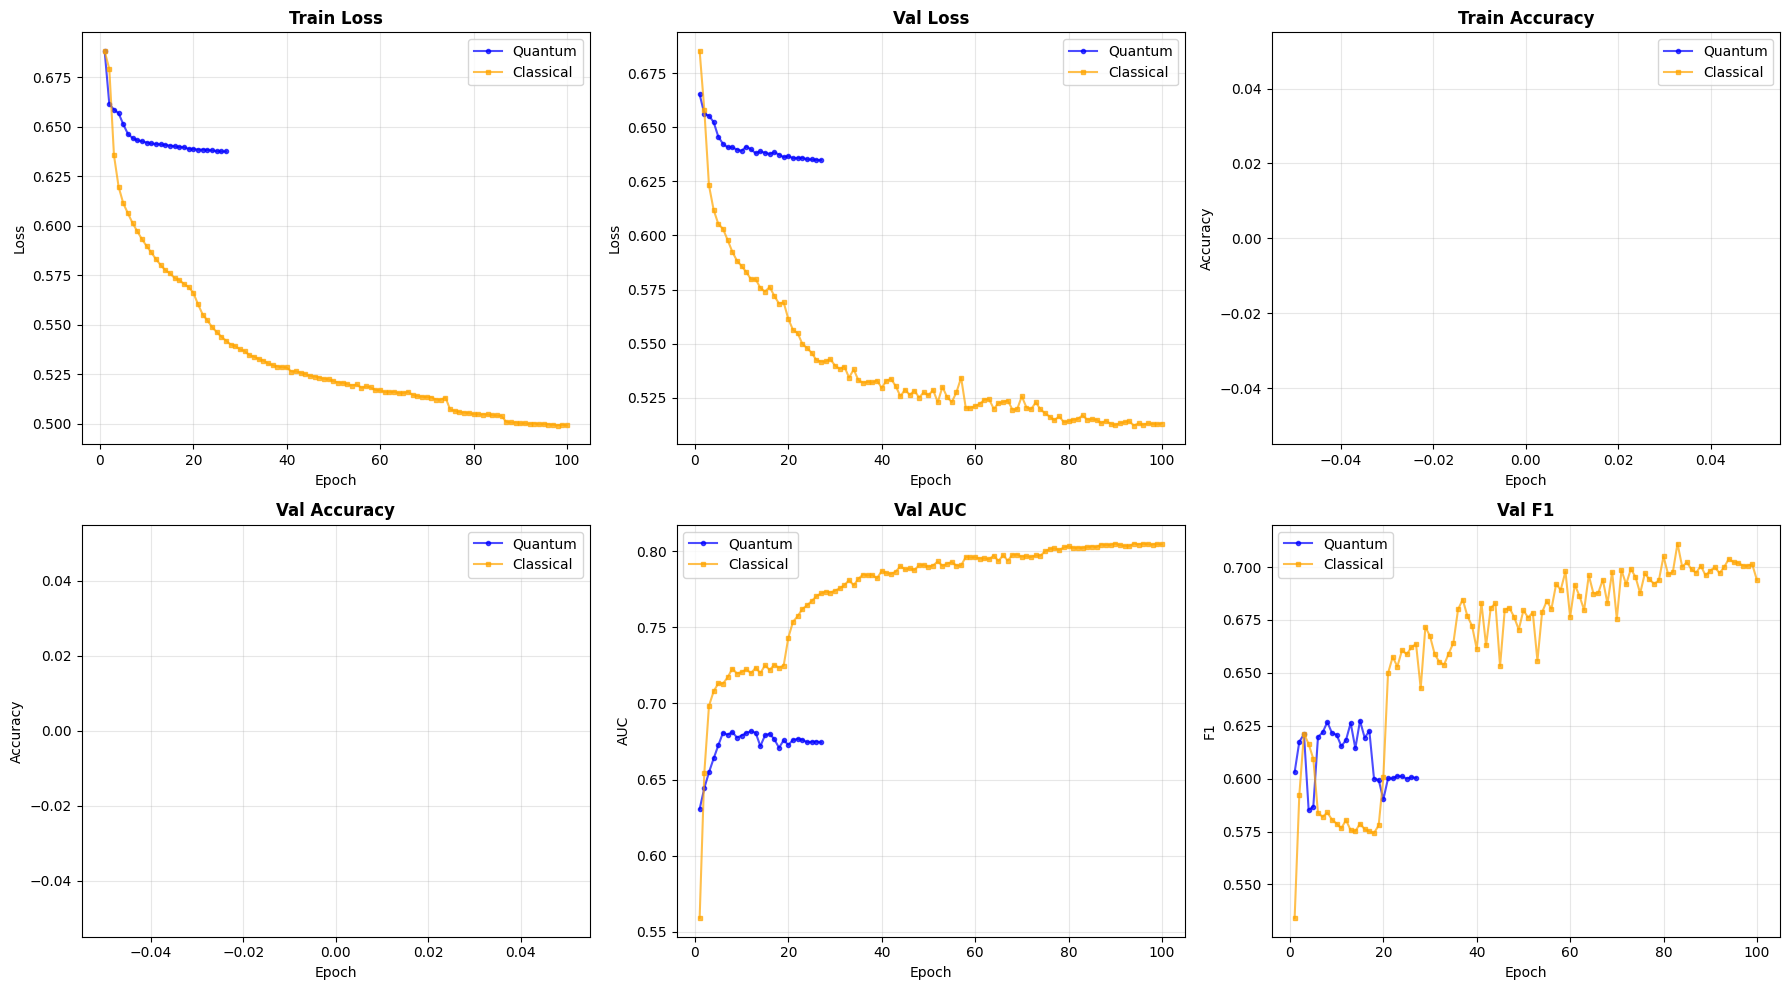


Plots saved to ./ligand_pocket_comparison_results/comparison_plots.png
Quantum model trained for 27 epochs
Classical model trained for 100 epochs


In [13]:
# Plot only actual epochs completed (no padding)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [('train_loss', 'Train Loss'), ('val_loss', 'Val Loss'), 
           ('train_acc', 'Train Accuracy'), ('val_acc', 'Val Accuracy'),
           ('val_auc', 'Val AUC'), ('val_f1', 'Val F1')]

for idx, (key, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    # Plot only actual epochs (no padding)
    q_epochs = np.arange(1, len(quantum_history[key]) + 1)
    c_epochs = np.arange(1, len(classical_history[key]) + 1)
    
    ax.plot(q_epochs, quantum_history[key], label='Quantum', color='blue', alpha=0.7, marker='o', markersize=3)
    ax.plot(c_epochs, classical_history[key], label='Classical', color='orange', alpha=0.7, marker='s', markersize=3)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title.split()[-1])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparison_plots.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\nPlots saved to {SAVE_DIR}/comparison_plots.png")
print(f"Quantum model trained for {len(quantum_history['train_loss'])} epochs")
print(f"Classical model trained for {len(classical_history['train_loss'])} epochs")